<a href="https://colab.research.google.com/github/deekshdechamma/DL_skill_developer/blob/main/dl4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kagglehub

In [2]:
#Step 2 — Import libraries
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


In [4]:
path = kagglehub.dataset_download(
    "uciml/pima-indians-diabetes-database"
)

print("Dataset downloaded to:")
print(path)

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Dataset downloaded to:
/kaggle/input/pima-indians-diabetes-database


In [5]:
#Step 4 — Find the CSV file
import os

print("Files in dataset:")

for file in os.listdir(path):
    print(file)

Files in dataset:
diabetes.csv


In [6]:
#Step 5 — Load the dataset
csv_path = os.path.join(
    path,
    "diabetes.csv"
)

df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
#Step 6 — Check the dataset
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

Dataset Shape:
(768, 9)

Column Names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [9]:
#Step 7 — Check missing values
print("Missing Values:")

print(df.isnull().sum())

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [10]:
#Step 8 — Separate features and target
X = df.drop(
    "Outcome",
    axis=1
).values

y = df[
    "Outcome"
].values.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768, 1)


In [11]:
#Step 9 — Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (614, 8)
Testing samples: (154, 8)


In [13]:
#Step 10 — Standardize the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [14]:
#Step 11 — Convert data to PyTorch tensors
X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.float32
)

y_test = torch.tensor(
    y_test,
    dtype=torch.float32
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([614, 8])
y_train: torch.Size([614, 1])
X_test: torch.Size([154, 8])
y_test: torch.Size([154, 1])


In [15]:
#Step 12 — Initialize neural-network parameters

def initialize_parameters():

    W1 = torch.randn(8, 16) * 0.1
    b1 = torch.zeros(1, 16)

    W2 = torch.randn(16, 8) * 0.1
    b2 = torch.zeros(1, 8)

    W3 = torch.randn(8, 1) * 0.1
    b3 = torch.zeros(1, 1)

    params = [
        W1, b1,
        W2, b2,
        W3, b3
    ]

    for p in params:
        p.requires_grad_(True)

    return params

In [16]:
#Step 13 — Forward propagation
def forward(X, params):

    W1, b1, W2, b2, W3, b3 = params

    # Hidden layer 1
    z1 = X @ W1 + b1
    a1 = torch.relu(z1)

    # Hidden layer 2
    z2 = a1 @ W2 + b2
    a2 = torch.relu(z2)

    # Output layer
    z3 = a2 @ W3 + b3

    output = torch.sigmoid(z3)

    return output

In [17]:
#Step 14 — Binary Cross-Entropy loss
def binary_cross_entropy(y_pred, y_true):

    epsilon = 1e-8

    loss = -torch.mean(
        y_true * torch.log(y_pred + epsilon)
        +
        (1 - y_true) *
        torch.log(1 - y_pred + epsilon)
    )

    return loss

In [19]:
#Step 15 — Custom Momentum optimizer
class MomentumOptimizer:

    def __init__(
        self,
        params,
        lr=0.01,
        beta=0.9
    ):

        self.params = params
        self.lr = lr
        self.beta = beta

        self.velocity = [
            torch.zeros_like(p)
            for p in params
        ]

    def zero_grad(self):

        for p in self.params:

            if p.grad is not None:
                p.grad.zero_()

    def step(self):

        with torch.no_grad():

            for i, p in enumerate(self.params):

                self.velocity[i] = (
                    self.beta *
                    self.velocity[i]
                    +
                    (1 - self.beta) *
                    p.grad
                )

                p -= (
                    self.lr *
                    self.velocity[i]
                )

In [20]:
#Step 16 — Custom RMSprop optimizer
class RMSpropOptimizer:

    def __init__(
        self,
        params,
        lr=0.01,
        beta=0.9,
        eps=1e-8
    ):

        self.params = params
        self.lr = lr
        self.beta = beta
        self.eps = eps

        self.square_avg = [
            torch.zeros_like(p)
            for p in params
        ]

    def zero_grad(self):

        for p in self.params:

            if p.grad is not None:
                p.grad.zero_()

    def step(self):

        with torch.no_grad():

            for i, p in enumerate(self.params):

                self.square_avg[i] = (
                    self.beta *
                    self.square_avg[i]
                    +
                    (1 - self.beta) *
                    (p.grad ** 2)
                )

                p -= (
                    self.lr *
                    p.grad
                    /
                    (
                        torch.sqrt(
                            self.square_avg[i]
                        )
                        + self.eps
                    )
                )

In [28]:
import torch
import numpy as np

class AdamOptimizer:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):

        self.params = list(params)
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon

        # First moment
        self.m = [torch.zeros_like(p) for p in self.params]

        # Second moment
        self.v = [torch.zeros_like(p) for p in self.params]

        # Time step
        self.t = 0

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

    def step(self):

        self.t += 1

        with torch.no_grad():

            for i, p in enumerate(self.params):

                if p.grad is None:
                    continue

                grad = p.grad

                # Update first moment
                self.m[i] = (
                    self.beta1 * self.m[i]
                    + (1 - self.beta1) * grad
                )

                # Update second moment
                self.v[i] = (
                    self.beta2 * self.v[i]
                    + (1 - self.beta2) * grad.pow(2)
                )

                # Bias correction
                m_hat = self.m[i] / (1 - self.beta1 ** self.t)

                v_hat = self.v[i] / (1 - self.beta2 ** self.t)

                # Adam parameter update
                p -= self.lr * m_hat / (
                    torch.sqrt(v_hat) + self.epsilon
                )

In [30]:
# Sample dataset
torch.manual_seed(42)

X = torch.randn(100, 1)

y = 3 * X + 2 + 0.2 * torch.randn(100, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([100, 1])
y shape: torch.Size([100, 1])


In [31]:
model = torch.nn.Linear(1, 1)

loss_function = torch.nn.MSELoss()

optimizer = AdamOptimizer(
    model.parameters(),
    lr=0.01
)

In [32]:
epochs = 500

loss_history = []

for epoch in range(epochs):

    # Clear old gradients
    optimizer.zero_grad()

    # Forward pass
    predictions = model(X)

    # Calculate loss
    loss = loss_function(predictions, y)

    # Backpropagation
    loss.backward()

    # Update weights using our custom Adam
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Loss: {loss.item():.6f}"
        )

Epoch [50/500], Loss: 4.739103
Epoch [100/500], Loss: 2.717490
Epoch [150/500], Loss: 1.532489
Epoch [200/500], Loss: 0.846846
Epoch [250/500], Loss: 0.454201
Epoch [300/500], Loss: 0.237558
Epoch [350/500], Loss: 0.125211
Epoch [400/500], Loss: 0.071082
Epoch [450/500], Loss: 0.046940
Epoch [500/500], Loss: 0.036978


In [33]:
print("\nTraining Completed")

print("Learned Weight:")
print(model.weight.data)

print("Learned Bias:")
print(model.bias.data)


Training Completed
Learned Weight:
tensor([[2.9258]])
Learned Bias:
tensor([2.0141])


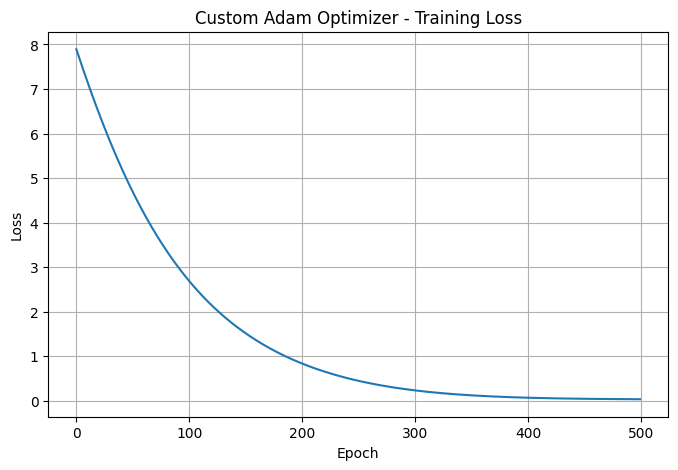

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom Adam Optimizer - Training Loss")

plt.grid(True)

plt.show()

In [25]:
#Step 18 — Create training function
def train_model(
    optimizer_name,
    epochs=1000
):

    torch.manual_seed(42)

    params = initialize_parameters()

    if optimizer_name == "Momentum":

        optimizer = MomentumOptimizer(
            params,
            lr=0.05,
            beta=0.9
        )

    elif optimizer_name == "RMSprop":

        optimizer = RMSpropOptimizer(
            params,
            lr=0.01,
            beta=0.9
        )

    elif optimizer_name == "Adam":

        optimizer = AdamOptimizer(
            params,
            lr=0.01,
            beta1=0.9,
            beta2=0.999
        )

    losses = []

    for epoch in range(epochs):

        # Forward pass
        predictions = forward(
            X_train,
            params
        )

        # Calculate loss
        loss = binary_cross_entropy(
            predictions,
            y_train
        )

        # Clear previous gradients
        optimizer.zero_grad()

        # Calculate gradients
        loss.backward()

        # Custom optimizer update
        optimizer.step()

        losses.append(
            loss.item()
        )

        if (epoch + 1) % 100 == 0:

            print(
                f"{optimizer_name} | "
                f"Epoch {epoch+1} | "
                f"Loss = {loss.item():.4f}"
            )

    return params, losses

In [40]:
#Step 19 — Train with Momentum
momentum_params, momentum_losses = train_model(
    "Momentum"
)

Momentum | Epoch 100 | Loss = 0.6438
Momentum | Epoch 200 | Loss = 0.6236
Momentum | Epoch 300 | Loss = 0.5701
Momentum | Epoch 400 | Loss = 0.5088
Momentum | Epoch 500 | Loss = 0.4802
Momentum | Epoch 600 | Loss = 0.4669
Momentum | Epoch 700 | Loss = 0.4586
Momentum | Epoch 800 | Loss = 0.4526
Momentum | Epoch 900 | Loss = 0.4478
Momentum | Epoch 1000 | Loss = 0.4432


In [41]:
#Step 20 — Train with RMSprop
rmsprop_params, rmsprop_losses = train_model(
    "RMSprop"
)

RMSprop | Epoch 100 | Loss = 0.3783
RMSprop | Epoch 200 | Loss = 0.3393
RMSprop | Epoch 300 | Loss = 0.3142
RMSprop | Epoch 400 | Loss = 0.2916
RMSprop | Epoch 500 | Loss = 0.2816
RMSprop | Epoch 600 | Loss = 0.2683
RMSprop | Epoch 700 | Loss = 0.2617
RMSprop | Epoch 800 | Loss = 0.2615
RMSprop | Epoch 900 | Loss = 0.2597
RMSprop | Epoch 1000 | Loss = 0.2597


In [42]:
#Step 21 — Train with Adam
adam_params, adam_losses = train_model(
    "Adam"
)

Adam | Epoch 100 | Loss = 0.3435
Adam | Epoch 200 | Loss = 0.2154
Adam | Epoch 300 | Loss = 0.1553
Adam | Epoch 400 | Loss = 0.1147
Adam | Epoch 500 | Loss = 0.0926
Adam | Epoch 600 | Loss = 0.0712
Adam | Epoch 700 | Loss = 0.0570
Adam | Epoch 800 | Loss = 0.0484
Adam | Epoch 900 | Loss = 0.0413
Adam | Epoch 1000 | Loss = 0.0365


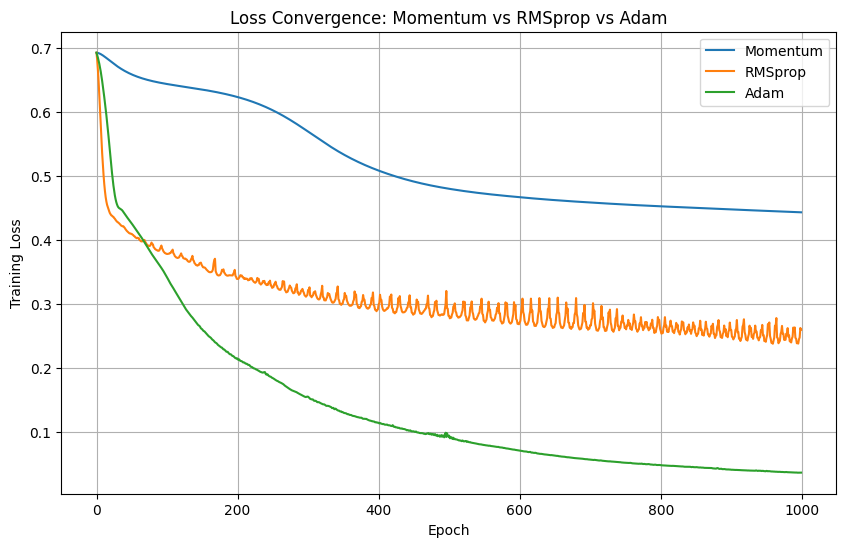

In [45]:
#Step 22 — Plot convergence graph

# This graph directly addresses "tracking loss convergence rates" from your assignment.

plt.figure(figsize=(10, 6))

plt.plot(
    momentum_losses,
    label="Momentum"
)

plt.plot(
    rmsprop_losses,
    label="RMSprop"
)

plt.plot(
    adam_losses,
    label="Adam"
)

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title(
    "Loss Convergence: Momentum vs RMSprop vs Adam"
)

plt.legend()

plt.grid(True)

plt.show()

In [46]:
#Step 23 — Calculate test accuracy
def calculate_accuracy(
    X,
    y,
    params
):

    with torch.no_grad():

        predictions = forward(
            X,
            params
        )

        predicted_labels = (
            predictions >= 0.5
        ).float()

        accuracy = (
            predicted_labels == y
        ).float().mean()

    return accuracy.item() * 100

In [47]:
#Step 24 — Compare test accuracy
momentum_accuracy = calculate_accuracy(
    X_test,
    y_test,
    momentum_params
)

rmsprop_accuracy = calculate_accuracy(
    X_test,
    y_test,
    rmsprop_params
)

adam_accuracy = calculate_accuracy(
    X_test,
    y_test,
    adam_params
)

print(
    f"Momentum Accuracy: "
    f"{momentum_accuracy:.2f}%"
)

print(
    f"RMSprop Accuracy: "
    f"{rmsprop_accuracy:.2f}%"
)

print(
    f"Adam Accuracy: "
    f"{adam_accuracy:.2f}%"
)

Momentum Accuracy: 71.43%
RMSprop Accuracy: 66.88%
Adam Accuracy: 77.27%


In [50]:
#Step 25 — Final comparison
print("\nOPTIMIZER COMPARISON")
print("-" * 50)

print(
    f"{'Optimizer':<15}"
    f"{'Final Loss':<15}"
    f"{'Test Accuracy':<15}"
)

print("-" * 50)

print(
    f"{'Momentum':<15}"
    f"{momentum_losses[-1]:<15.6f}"
    f"{momentum_accuracy:<15.2f}"
)

print(
    f"{'RMSprop':<15}"
    f"{rmsprop_losses[-1]:<15.6f}"
    f"{rmsprop_accuracy:<15.2f}"
)

print(
    f"{'Adam':<15}"
    f"{adam_losses[-1]:<15.6f}"
    f"{adam_accuracy:<15.2f}"
)


OPTIMIZER COMPARISON
--------------------------------------------------
Optimizer      Final Loss     Test Accuracy  
--------------------------------------------------
Momentum       0.443227       71.43          
RMSprop        0.259728       66.88          
Adam           0.036547       77.27          
